In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/delhi_metro_updated.csv')
df

,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks
0,59771,2022-05-08,Inderlok,Kashmere Gate,12.94,77.99,18.27,13.0,Smart Card,maintenance
1,21363,2023-01-12,Model Town,Dilshad Garden,2.33,35.89,83.71,15.0,Tourist Card,maintenance
2,127325,2023-07-13,Kashmere Gate,Netaji Subhash Place,5.56,64.35,43.70,9.0,Single,off-peak
3,140510,2022-11-10,Chandni Chowk,Hauz Khas,4.02,144.13,14.98,27.0,NaN,maintenance
4,144298,2022-11-06,Rajiv Chowk,Kalkaji Mandir,9.66,104.96,83.84,23.0,Single,off-peak
...,...,...,...,...,...,...,...,...,...,...
85101,112373,2023-02-12,Rajiv Chowk,Rajouri Garden,2.39,48.45,53.15,18.0,Tourist Card,peak
85102,84715,2024-09-11,Rajiv Chowk,Inderlok,3.03,48.40,79.39,15.0,Tourist Card,maintenance
85103,22592,2024-12-26,MODEL TOWN,Rajouri Garden,2.26,126.10,93.47,18.0,Single,peak
85104,92234,2023-12-26,DILSHAD GARDEN,Kashmere Gate,2.47,85.71,56.03,16.0,Tourist Card,peak


In [ ]:
df.head(10)

,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks
0,59771,2022-05-08,Inderlok,Kashmere Gate,12.94,77.99,18.27,13.0,Smart Card,maintenance
1,21363,2023-01-12,Model Town,Dilshad Garden,2.33,35.89,83.71,15.0,Tourist Card,maintenance
2,127325,2023-07-13,Kashmere Gate,Netaji Subhash Place,5.56,64.35,43.70,9.0,Single,off-peak
3,140510,2022-11-10,Chandni Chowk,Hauz Khas,4.02,144.13,14.98,27.0,NaN,maintenance
4,144298,2022-11-06,Rajiv Chowk,Kalkaji Mandir,9.66,104.96,83.84,23.0,Single,off-peak
5,96371,2024-07-10,Kalkaji Mandir,Shivaji Park,3.91,29.20,30.64,22.0,Tourist Card,NaN
6,49743,2022-09-02,Mandi House,Jasola Vihar,1.49,175.32,33.45,14.0,Tourist Card,peak
7,47390,2023-12-07,Mandi House,Central Secretariat,7.38,167.59,50.69,18.0,Tourist Card,festival
8,58379,2024-05-05,AIIMS,Chandni Chowk,2.57,125.25,81.71,24.0,Single,weekend
9,69048,2022-07-05,New Delhi,Jasola Vihar,7.58,151.39,37.76,19.0,Tourist Card,peak


In [ ]:
df.tail(10)

,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks
85096,59155,2024-10-07,Noida City Centre,Laxmi Nagar,0.80,31.93,61.15,20.0,Tourist Card,off-peak
85097,51165,2022-07-01,Central Secretariat,Rajiv Chowk,0.76,62.31,114.48,9.0,Tourist Card,weekend
85098,6989,2022-06-22,AIIMS,Punjabi Bagh,4.95,71.45,93.19,19.0,Tourist Card,weekend
85099,15014,2023-05-29,Noida City Centre,Barakhamba Road,2.03,94.07,85.19,19.0,Tourist Card,off-peak
85100,9396,2022-01-09,Laxmi Nagar,Mandi House,9.36,168.59,100.06,15.0,Single,festival
85101,112373,2023-02-12,Rajiv Chowk,Rajouri Garden,2.39,48.45,53.15,18.0,Tourist Card,peak
85102,84715,2024-09-11,Rajiv Chowk,Inderlok,3.03,48.40,79.39,15.0,Tourist Card,maintenance
85103,22592,2024-12-26,MODEL TOWN,Rajouri Garden,2.26,126.10,93.47,18.0,Single,peak
85104,92234,2023-12-26,DILSHAD GARDEN,Kashmere Gate,2.47,85.71,56.03,16.0,Tourist Card,peak
85105,52718,2023-01-12,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85106 entries, 0 to 85105
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TripID              85106 non-null  int64  
 1   Date                85106 non-null  object 
 2   From_Station        85106 non-null  object 
 3   To_Station          85105 non-null  object 
 4   Distance_km         85105 non-null  float64
 5   Fare                85105 non-null  float64
 6   Cost_per_passenger  85105 non-null  float64
 7   Passengers          84295 non-null  float64
 8   Ticket_Type         84235 non-null  object 
 9   Remarks             70242 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 6.5+ MB


In [ ]:
df.describe()

,TripID,Distance_km,Fare,Cost_per_passenger,Passengers
count,85106.000000,85105.000000,85105.000000,85105.000000,84295.000000
mean,75161.884356,5.484402,105.172305,62.445878,20.019800
std,43266.553300,4.997034,54.800933,33.220506,4.457677
min,1.000000,0.500000,10.000000,5.000000,5.000000
25%,37770.500000,1.930000,57.650000,33.630000,17.000000
50%,75148.500000,3.940000,105.380000,62.480000,20.000000
75%,112709.750000,7.400000,152.440000,91.150000,23.000000
max,149998.000000,63.030000,200.000000,120.000000,40.000000


In [ ]:
df.shape

(85106, 10)

In [ ]:
df.columns

Index(['TripID', 'Date', 'From_Station', 'To_Station', 'Distance_km', 'Fare',
       'Cost_per_passenger', 'Passengers', 'Ticket_Type', 'Remarks'],
      dtype='object')

In [ ]:
# Missing Values
print(df.isnull().sum())

TripID                    0
Date                      0
From_Station              0
To_Station                1
Distance_km               1
Fare                      1
Cost_per_passenger        1
Passengers              811
Ticket_Type             871
Remarks               14864
dtype: int64


In [ ]:
#To check duplicate values.
df.duplicated().sum()

np.int64(0)

In [ ]:
# Treating the missing values.
# Drop the rows where columns are having minor missing values.
df.dropna(subset=['To_Station','Distance_km','Fare','Cost_per_passenger'],inplace=True)

In [ ]:
print(df['Passengers'].value_counts())

Passengers
20.0    7705
19.0    7579
21.0    7131
18.0    7070
17.0    6423
22.0    6382
23.0    5667
16.0    5367
24.0    4753
15.0    4330
25.0    3802
14.0    3190
26.0    2913
13.0    2262
27.0    2105
28.0    1462
12.0    1399
29.0    1070
11.0     910
30.0     730
10.0     472
31.0     467
32.0     278
9.0      246
33.0     170
8.0      120
34.0     109
35.0      61
7.0       46
36.0      32
37.0      17
6.0       14
5.0        4
38.0       4
39.0       3
40.0       2
Name: count, dtype: int64


In [ ]:
# using mode to replace missing value.
df['Passengers'] = df['Passengers'].fillna(df['Passengers'].mode()[0])
df['Ticket_Type'] = df['Ticket_Type'].fillna(df['Ticket_Type'].mode()[0])
df['Remarks'] = df['Remarks'].fillna(df['Remarks'].mode()[0])

In [ ]:
# Missing Values Treated
print(df.isnull().sum())

TripID                0
Date                  0
From_Station          0
To_Station            0
Distance_km           0
Fare                  0
Cost_per_passenger    0
Passengers            0
Ticket_Type           0
Remarks               0
dtype: int64


In [ ]:
# separate Numerical & categorical Columns
num_cols = df.select_dtypes(include = ['int64','float64']).columns
num_cols

Index(['TripID', 'Distance_km', 'Fare', 'Cost_per_passenger', 'Passengers'], dtype='object')

In [ ]:
cat_cols = df.select_dtypes(include = ['object','category']).columns
cat_cols

Index(['Date', 'From_Station', 'To_Station', 'Ticket_Type', 'Remarks'], dtype='object')

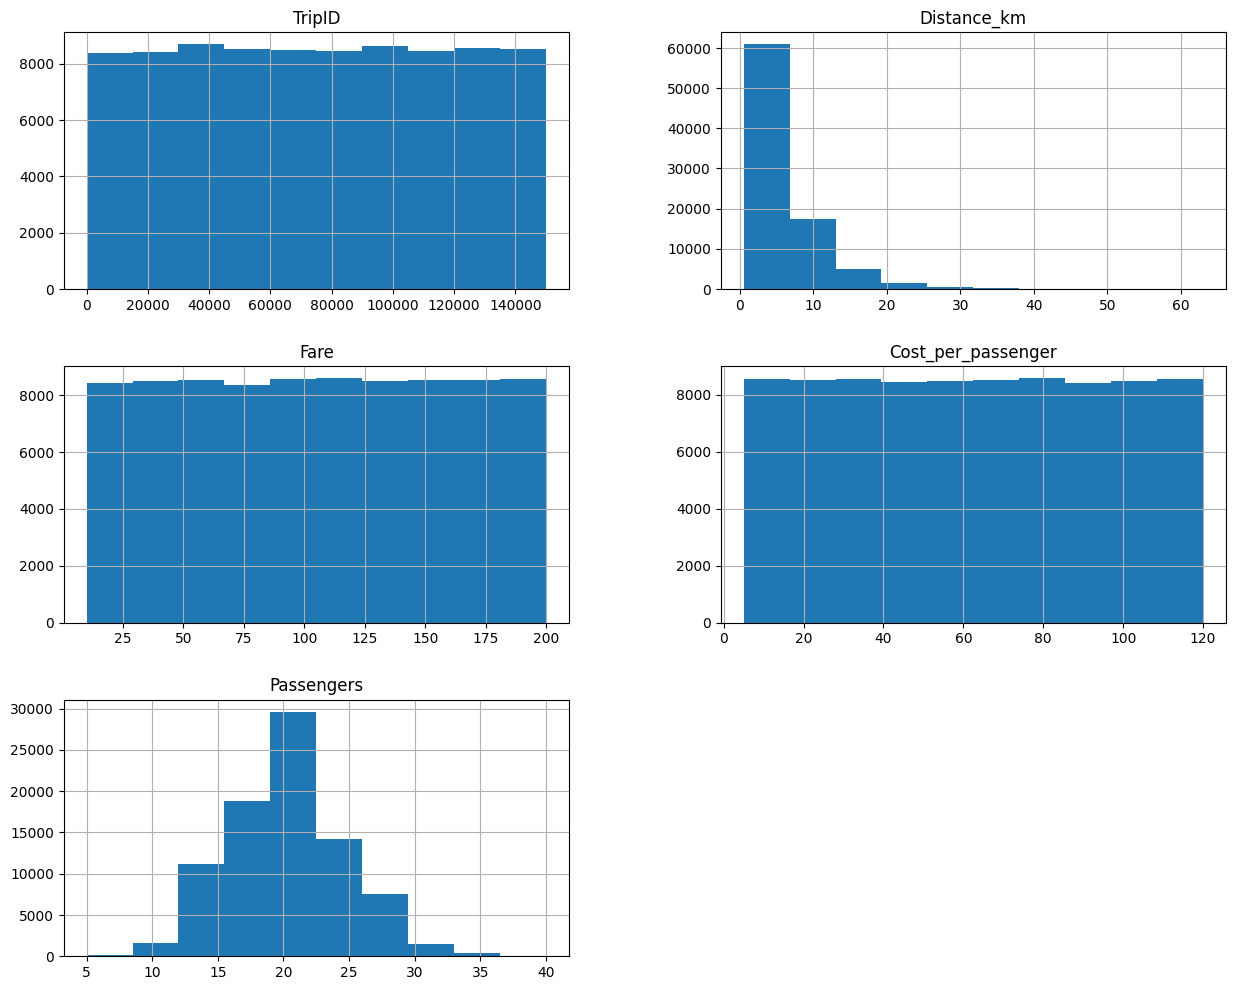

In [ ]:
# univariate Analysis
df.hist(figsize = (15,12)) # Histogram only works for the numerical data.
plt.show()

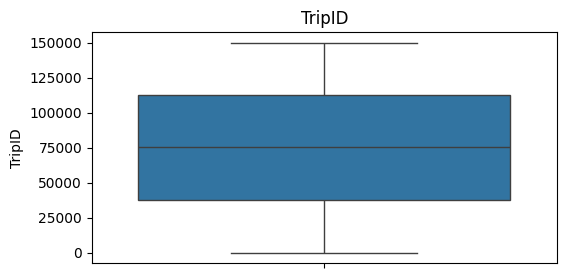

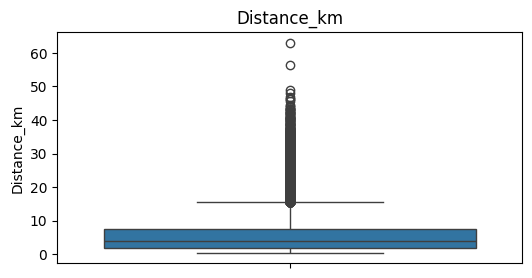

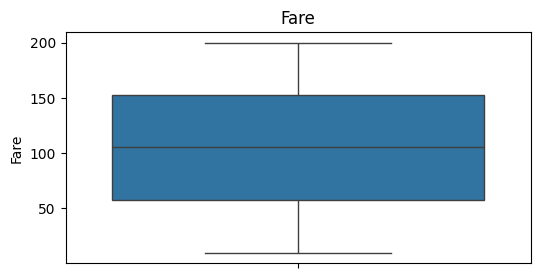

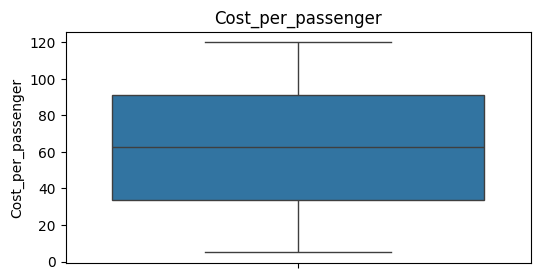

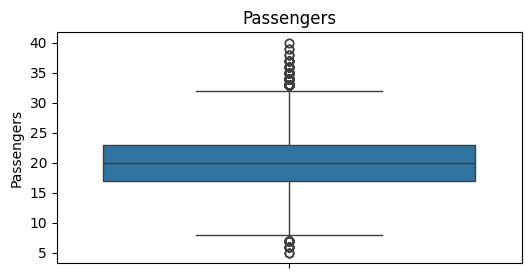

In [ ]:
# Box Plot

for col in num_cols:
  plt.figure(figsize = (6,3))
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

In [ ]:
exclude_cols = ['TripID','Fare','Cost_per_passenger']
num_cols = [col for col in num_cols if col not in exclude_cols] # Deleting extra columns..
print(num_cols)

['Distance_km', 'Passengers']


In [ ]:
# Outlier Treatment

for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3-Q1

  lower_range = Q1 - 1.5*IQR
  upper_range = Q3 + 1.5*IQR

  df[col] = np.where(df[col] > upper_range, upper_range, df[col])
  df[col] = np.where(df[col]< lower_range, lower_range, df[col])

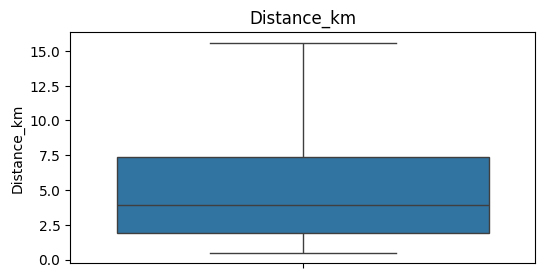

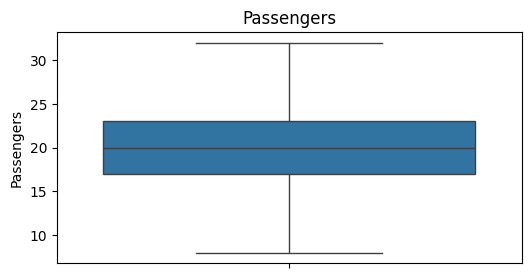

In [ ]:
# verifying

for col in num_cols:
  plt.figure(figsize =(6,3))
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

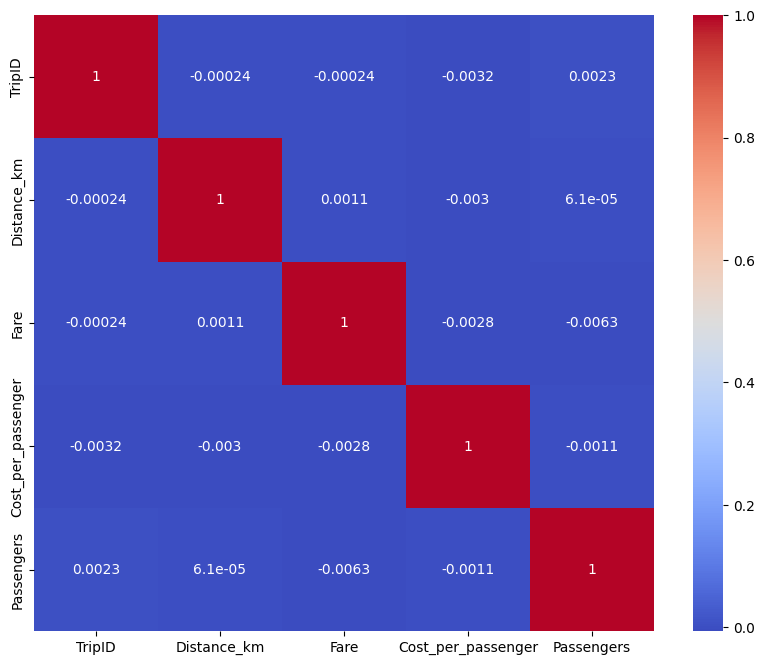

In [ ]:
# Correlation Analysis
# find the feature relationships

corr = df.corr(numeric_only=True)
plt.figure(figsize =(10,8))
sns.heatmap(corr, annot = True, cmap = 'coolwarm') # annot gives numerical representation inside the graph.
plt.show()                                         # cmap stands for Colormap — it controls the color scheme of the heatmap.

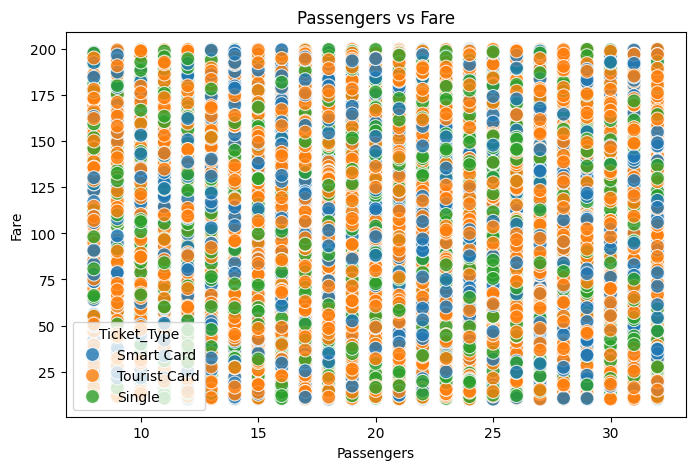

In [ ]:
# scatter plot
#to understand the relationship b/w 2 numerical values

plt.figure(figsize=(8,5))
sns.scatterplot(x = 'Passengers', y = 'Fare', hue='Ticket_Type', data = df, s= 100, alpha = 0.8)
plt.title('Passengers vs Fare')
plt.show()

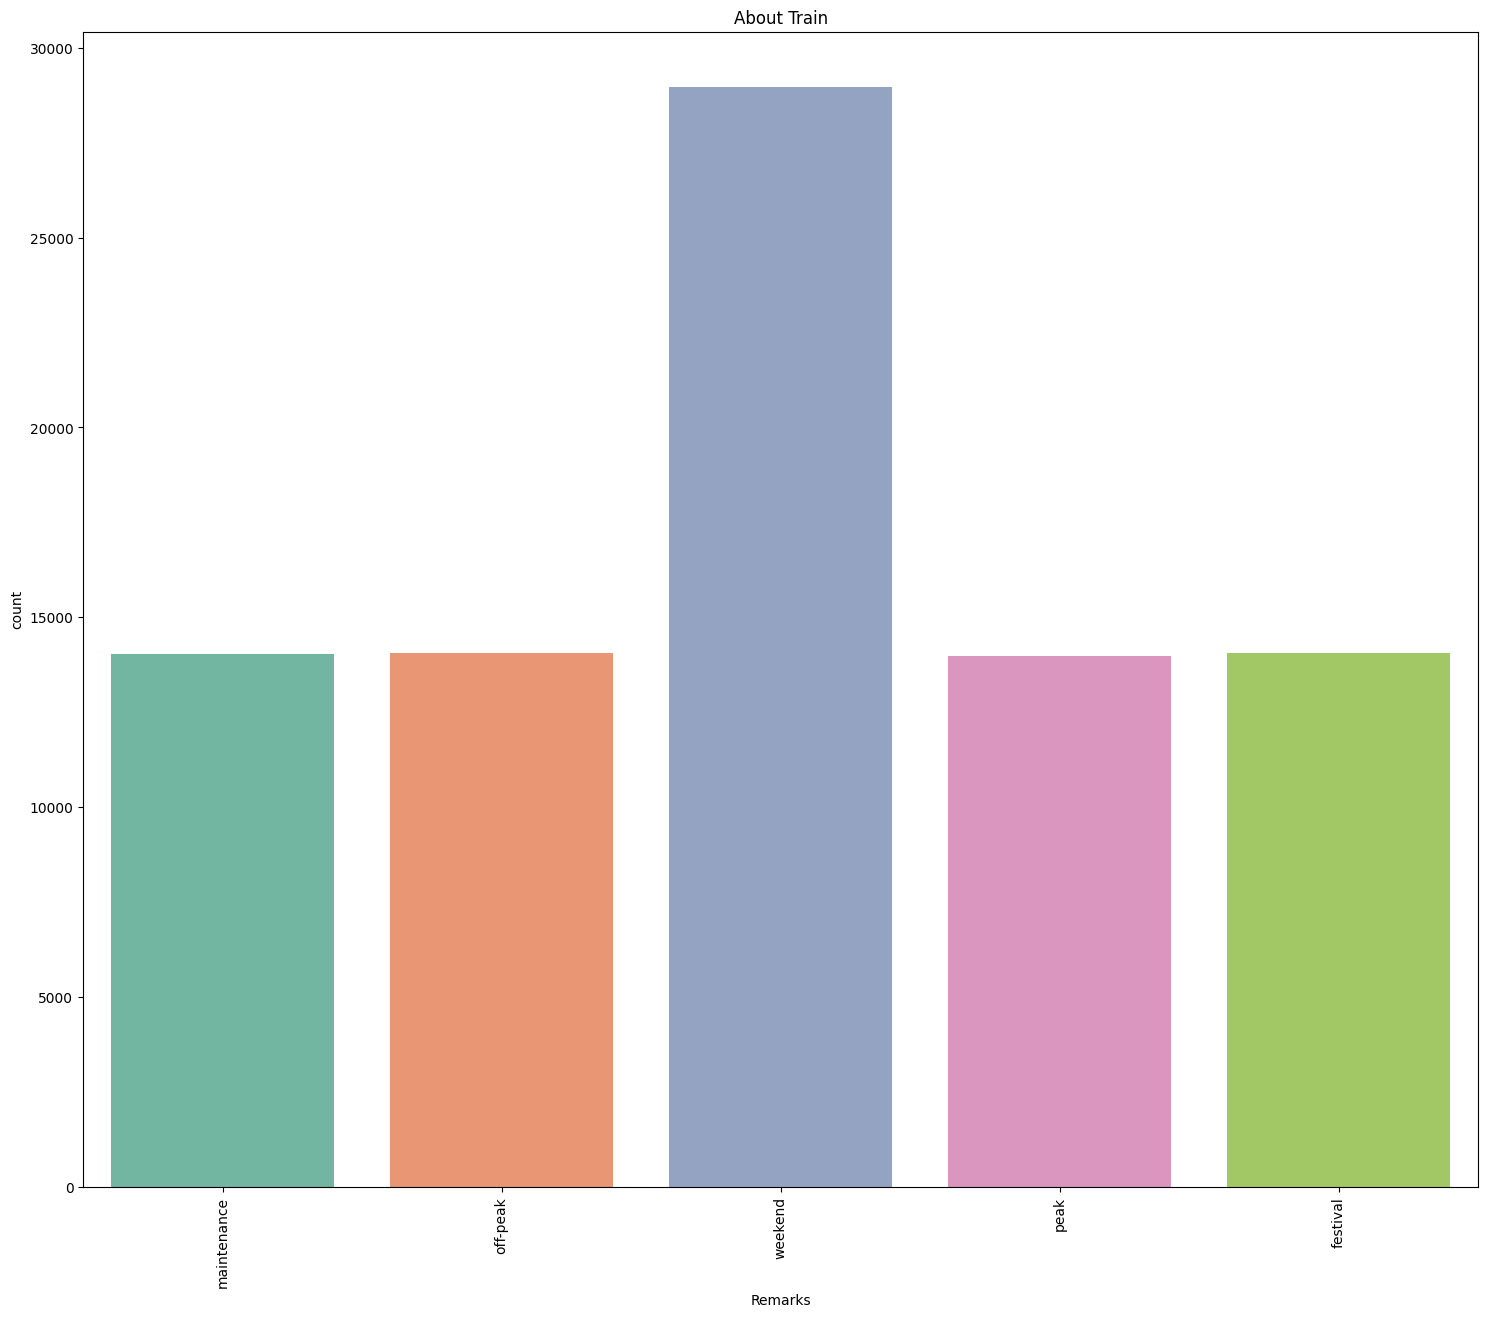

In [ ]:
# categorical analysis

plt.figure(figsize=(18,15))
sns.countplot(x = 'Remarks', data = df, palette = 'Set2')
plt.title('About Train')
plt.xticks(rotation = 90)
plt.show()

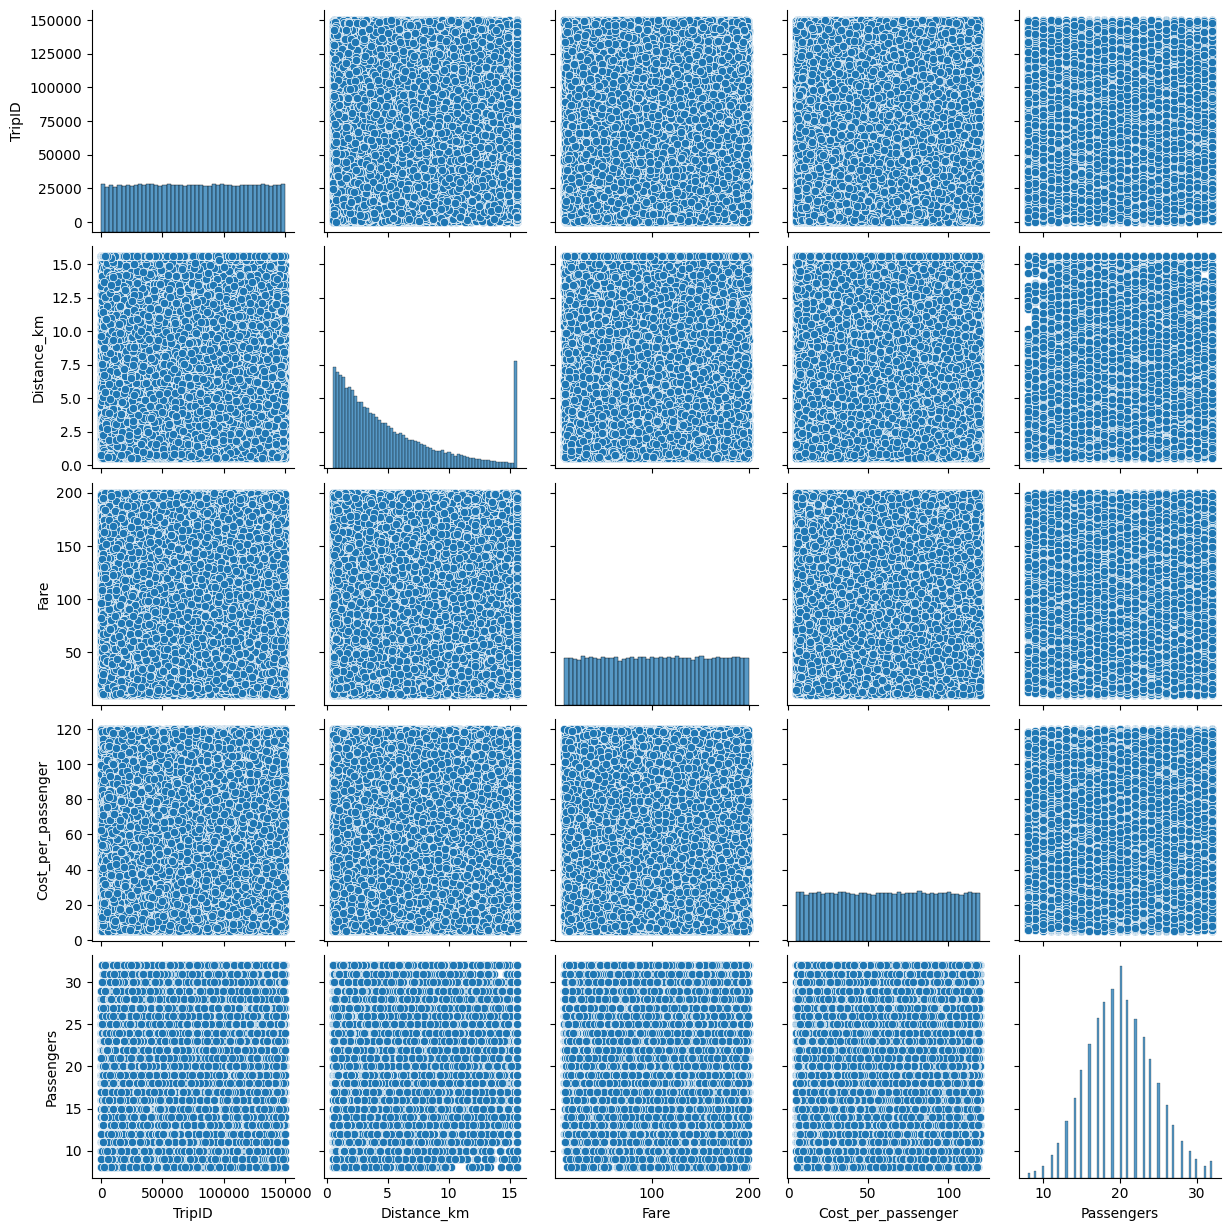

In [ ]:
# Multivariate Data
sns.pairplot(df)
plt.show()

In [ ]:
# creating a new feature = means creating a new columns using old columns.

df['Total_Revenue'] = df['Fare'] * df['Passengers']
df[['Fare','Passengers','Total_Revenue']].head()

,Fare,Passengers,Total_Revenue
0,77.99,13.0,1013.87
1,35.89,15.0,538.35
2,64.35,9.0,579.15
3,144.13,27.0,3891.51
4,104.96,23.0,2414.08


In [ ]:
# Encoding

cat_cols = df.select_dtypes(include = ['object']).columns
print(cat_cols)

Index(['Date', 'From_Station', 'To_Station', 'Ticket_Type', 'Remarks'], dtype='object')


In [ ]:
# Lable Encoding = giving unique number to every category.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
  df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
# check the result of previous code.
df.head()

,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks,Total_Revenue
0,59771,127,455,10,12.94,77.99,18.27,13.0,1,1,1013.87
1,21363,376,462,4,2.33,35.89,83.71,15.0,2,1,538.35
2,127325,558,56,15,5.56,64.35,43.70,9.0,0,2,579.15
3,140510,313,452,5,4.02,144.13,14.98,27.0,2,1,3891.51
4,144298,309,465,9,9.66,104.96,83.84,23.0,0,2,2414.08


In [ ]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() # Mean becomes 0 and standard deviation becomes 1
                          # z = x - mean/standard deviation
scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns = df.columns)
scaled_df.head()

,TripID,Date,From_Station,To_Station,Distance_km,Fare,Cost_per_passenger,Passengers,Ticket_Type,Remarks,Total_Revenue
0,-0.355729,-1.333392,0.402014,-0.214696,1.839088,-0.496022,-1.329785,-1.592183,-0.308193,-0.904262,-0.898737
1,-1.243437,-0.544599,0.461561,-1.081918,-0.695331,-1.264262,0.640094,-1.137968,0.899003,-0.904262,-1.291114
2,1.205618,0.031948,-2.992199,0.507990,0.076222,-0.744924,-0.564290,-2.500615,-1.515389,-0.234504,-1.257448
3,1.510357,-0.744173,0.376493,-0.937381,-0.291639,0.710899,-1.428821,1.587326,0.899003,-0.904262,1.475760
4,1.597908,-0.756845,0.487082,-0.359233,1.055592,-0.003874,0.644007,0.678895,-1.515389,-0.234504,0.256652


In [ ]:
# Final Dataset Preparation

scaled_df.to_csv('cleaned_ev_dataset.csv',index = False)
print("Dataset Saved Successfully")

Dataset Saved Successfully
